# Amazon Customer Behavior Analysis

**Objective:** Explore what drives Amazon customers' purchasing decisions, from demographics and browsing habits to product preferences, review reliance, and satisfaction.

---

## 1. Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("Amazon Customer Behavior Survey.csv")

## 2. Initial Exploration

In [3]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,2023/06/04 1:28:19 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023/06/04 2:30:44 PM GMT+5:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023/06/04 5:04:56 PM GMT+5:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,2023/06/04 5:13:00 PM GMT+5:30,24,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,2023/06/04 5:28:06 PM GMT+5:30,22,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,Filter,Multiple pages,1,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy


In [4]:
df.shape

(602, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               602 non-null    object
 1   age                                     602 non-null    int64 
 2   Gender                                  602 non-null    object
 3   Purchase_Frequency                      602 non-null    object
 4   Purchase_Categories                     602 non-null    object
 5   Personalized_Recommendation_Frequency   602 non-null    object
 6   Browsing_Frequency                      602 non-null    object
 7   Product_Search_Method                   600 non-null    object
 8   Search_Result_Exploration               602 non-null    object
 9   Customer_Reviews_Importance             602 non-null    int64 
 10  Add_to_Cart_Browsing                    602 non-null    object
 11  Cart_C

In [6]:
df.describe()

,age,Customer_Reviews_Importance,Personalized_Recommendation_Frequency,Rating_Accuracy,Shopping_Satisfaction
count,602.000000,602.000000,602.000000,602.000000,602.000000
mean,30.790698,2.480066,2.699336,2.672757,2.463455
std,10.193276,1.185226,1.042028,0.899744,1.012152
min,3.000000,1.000000,1.000000,1.000000,1.000000
25%,23.000000,1.000000,2.000000,2.000000,2.000000
50%,26.000000,3.000000,3.000000,3.000000,2.000000
75%,36.000000,3.000000,3.000000,3.000000,3.000000
max,67.000000,5.000000,5.000000,5.000000,5.000000


## 3. Data Cleaning & Feature Engineering

We remove rows with missing values in key columns, then engineer three new features:
- **Age Category** : groups customers into life-stage categories
- **Hour** : extracted from the timestamp
- **Time Category** : maps purchase hour to a time-of-day label (Morning / Afternoon / Evening / Night)

In [7]:
df.isna().sum()

,0
Timestamp,0
age,0
Gender,0
Purchase_Frequency,0
Purchase_Categories,0
Personalized_Recommendation_Frequency,0
Browsing_Frequency,0
Product_Search_Method,2
Search_Result_Exploration,0
Customer_Reviews_Importance,0


In [8]:
df = df.dropna(subset=['Product_Search_Method'])

In [9]:
# Age category
def add_age_category(row):
    x = row["age"]
    if x < 18:        return "Minor"
    elif x < 25:      return "Young Adult"
    elif x < 40:      return "Adult"
    else:             return "Middle Aged"

df["Age Category"] = df.apply(add_age_category, axis=1)

In [10]:
# Timestamp features
from datetime import timedelta

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Timestamp"] += timedelta(hours=5, minutes=30)   # adjusting time

df["Hour"]  = df["Timestamp"].dt.hour

/tmp/ipykernel_13539/909169673.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Timestamp"] = pd.to_datetime(df["Timestamp"])


In [11]:
# Time category
def time_period(row):
    h = row["Hour"]
    if   6 <= h <= 12:  return "Morning"
    elif 12 < h < 18:   return "Afternoon"
    elif 18 <= h <= 21: return "Evening"
    else:               return "Night"

df["Time Category"] = df.apply(time_period, axis=1)

In [12]:
# Reorder columns
priority_cols = ["Gender", "age", "Age Category", "Hour", "Time Category"]
remaining     = [c for c in df.columns if c not in priority_cols]
df = df[priority_cols + remaining]

df.head()

,Gender,age,Age Category,Hour,Time Category,Timestamp,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,Female,23,Young Adult,18,Evening,2023-06-04 18:58:19-05:30,Few times a month,Beauty and Personal Care,Yes,Few times a week,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,Female,23,Young Adult,20,Evening,2023-06-04 20:00:44-05:30,Once a month,Clothing and Fashion,Yes,Few times a month,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,Prefer not to say,24,Young Adult,22,Night,2023-06-04 22:34:56-05:30,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,Female,24,Young Adult,22,Night,2023-06-04 22:43:00-05:30,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,Female,22,Young Adult,22,Night,2023-06-04 22:58:06-05:30,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy


## 4. Customer Demographics

Understanding *who* shops on Amazon: gender split, age distribution, and when they're most active.

> **Key finding:** The dataset skews heavily female (~60 %), and most buyers are Adults (25–39) or Young Adults (18–24). Nearly 60 % of purchases happen at night, suggesting customers browse after work hours.

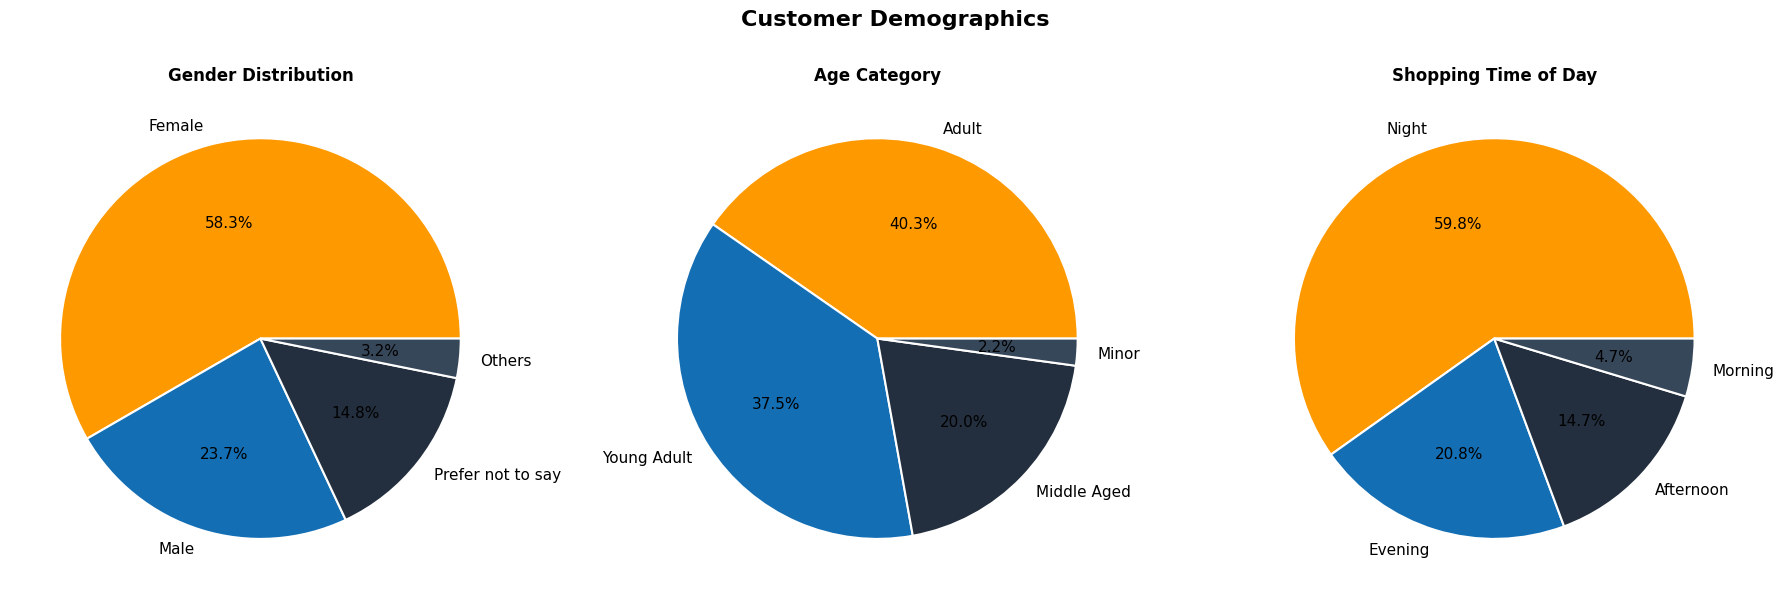

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

################### Shared style ###################
PALETTE   = ["#FF9900", "#146EB4", "#232F3E", "#37475A"]   # Amazon brand colors
PIE_STYLE = dict(
    autopct='%1.1f%%',
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=11)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Customer Demographics", fontsize=16, fontweight='bold', y=1.02)

# Gender
ax = axes[0]
gender_counts = df["Gender"].value_counts()
ax.pie(gender_counts, labels=gender_counts.index, colors=PALETTE, **PIE_STYLE)
ax.set_title("Gender Distribution", fontweight='bold')

# Age Category
ax = axes[1]
age_counts = df["Age Category"].value_counts()
ax.pie(age_counts, labels=age_counts.index, colors=PALETTE, **PIE_STYLE)
ax.set_title("Age Category", fontweight='bold')

# Time of Day
ax = axes[2]
time_counts = df["Time Category"].value_counts()
ax.pie(time_counts, labels=time_counts.index, colors=PALETTE, **PIE_STYLE)
ax.set_title("Shopping Time of Day", fontweight='bold')

plt.tight_layout()
plt.show()

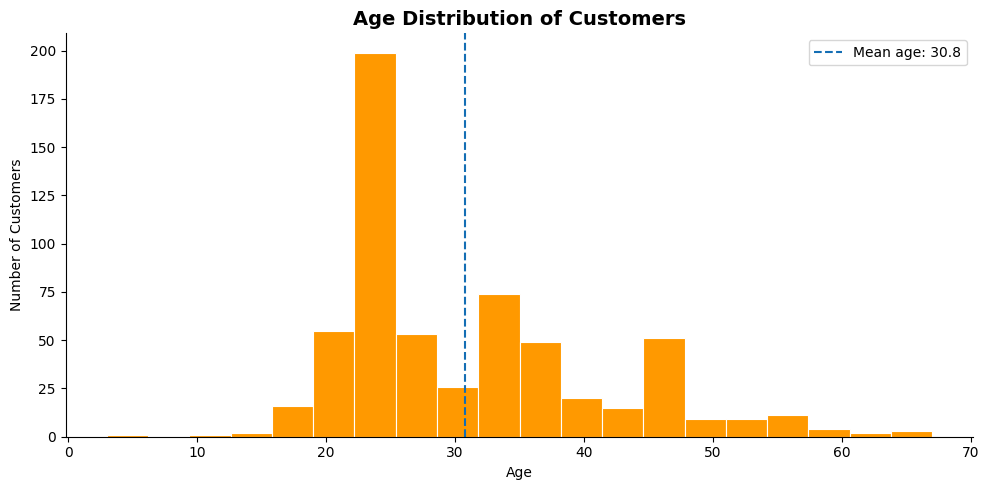

In [14]:
# Age distribution histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["age"], bins=20, color="#FF9900", edgecolor="white", linewidth=0.8)
ax.set_title("Age Distribution of Customers", fontsize=14, fontweight='bold')
ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")
ax.axvline(df["age"].mean(), color="#146EB4", linestyle="--", linewidth=1.5,
           label=f"Mean age: {df['age'].mean():.1f}")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_13539/1571055204.py:17: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_freq_gender, x="Purchase_Frequency", y="count", hue="Gender",


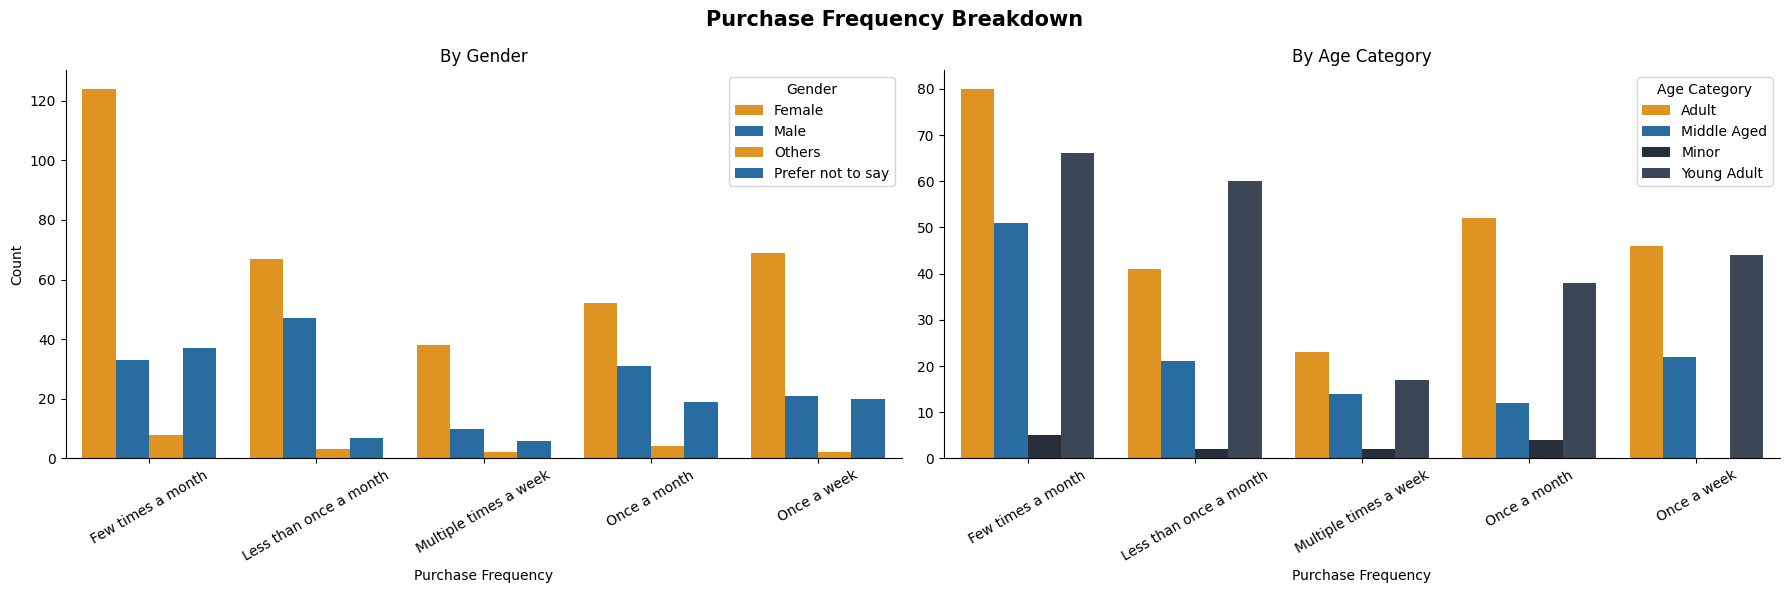

In [15]:
# Purchase frequency by gender and age category

df_freq_gender = (
    df.groupby(["Purchase_Frequency", "Gender"])
      .agg(count=("Gender", "count"))
      .reset_index()
)
df_freq_age = (
    df.groupby(["Purchase_Frequency", "Age Category"])
      .agg(count=("Age Category", "count"))
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Purchase Frequency Breakdown", fontsize=15, fontweight='bold')

sns.barplot(data=df_freq_gender, x="Purchase_Frequency", y="count", hue="Gender",
            palette=PALETTE[:2], ax=axes[0])
axes[0].set_title("By Gender")
axes[0].set_xlabel("Purchase Frequency")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=df_freq_age, x="Purchase_Frequency", y="count", hue="Age Category",
            palette=PALETTE, ax=axes[1])
axes[1].set_title("By Age Category")
axes[1].set_xlabel("Purchase Frequency")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=30)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Interpretation:**
- Women not only dominate the user base but also shop more frequently, they account for the majority of weekly and monthly buyers.
- Adults (25–39) are the most frequent shoppers, followed closely by Young Adults.
- Rare shoppers are more prevalent among Middle-Aged customers, suggesting they use Amazon for targeted, occasional purchases rather than habitual browsing.

## 5. Purchase Category Preferences

What product categories do different customer segments gravitate toward?

> **Key finding:** Beauty & Personal Care and Clothing & Fashion dominate overall especially among female customers.

In [16]:
import plotly.express as px

def make_pie(data, title):
    counts = data["Purchase_Categories"].value_counts()

    fig = px.pie(
        values=counts.values,
        names=counts.index,
        title=title
    )
    fig.show()

make_pie(df, "Overall Customers")
make_pie(df[df["Gender"] == "Female"], "Female Customers")
make_pie(df[df["Gender"] == "Male"], "Male Customers")

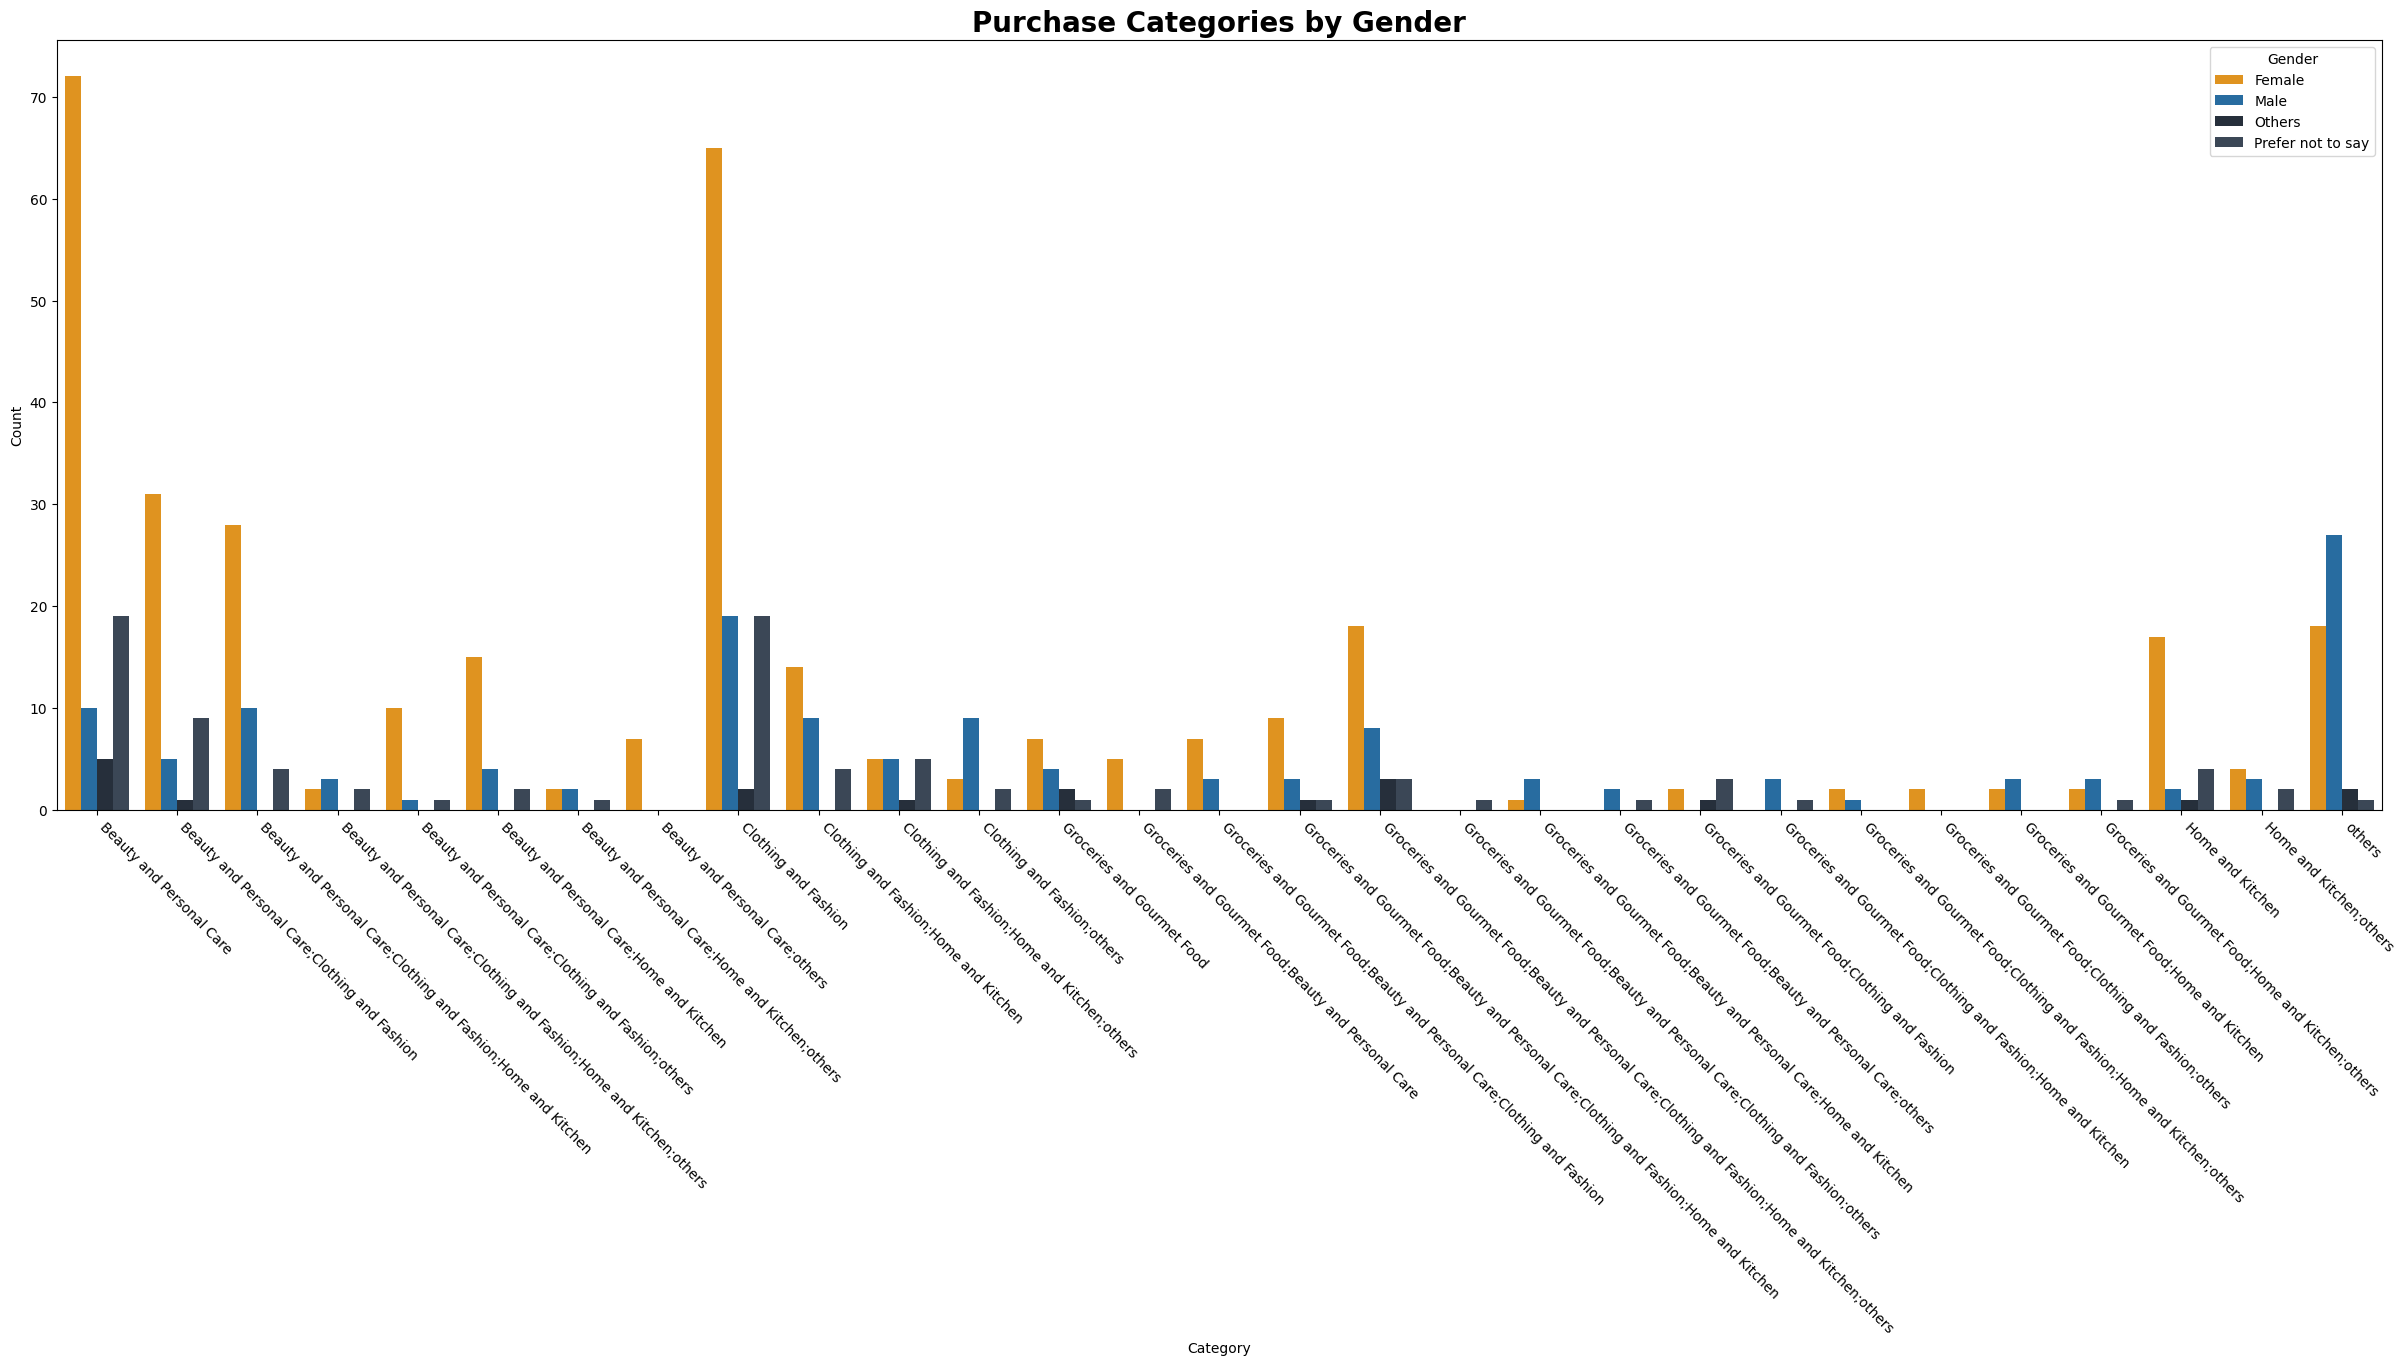

In [28]:
# Grouped bar: category × gender
df_cat_gender = (
    df.groupby(["Purchase_Categories", "Gender"])
      .agg(count=("Gender", "count"))
      .reset_index()
)

plt.figure(figsize=(18, 8))
sns.barplot(data=df_cat_gender, x="Purchase_Categories", y="count",
            hue="Gender", palette=PALETTE)
plt.title("Purchase Categories by Gender", fontsize=20, fontweight='bold')
plt.xlabel("Category",fontsize=10)
plt.ylabel("Count",fontsize=10)
plt.xticks(rotation=-45, ha='left',fontsize=10)

plt.show()

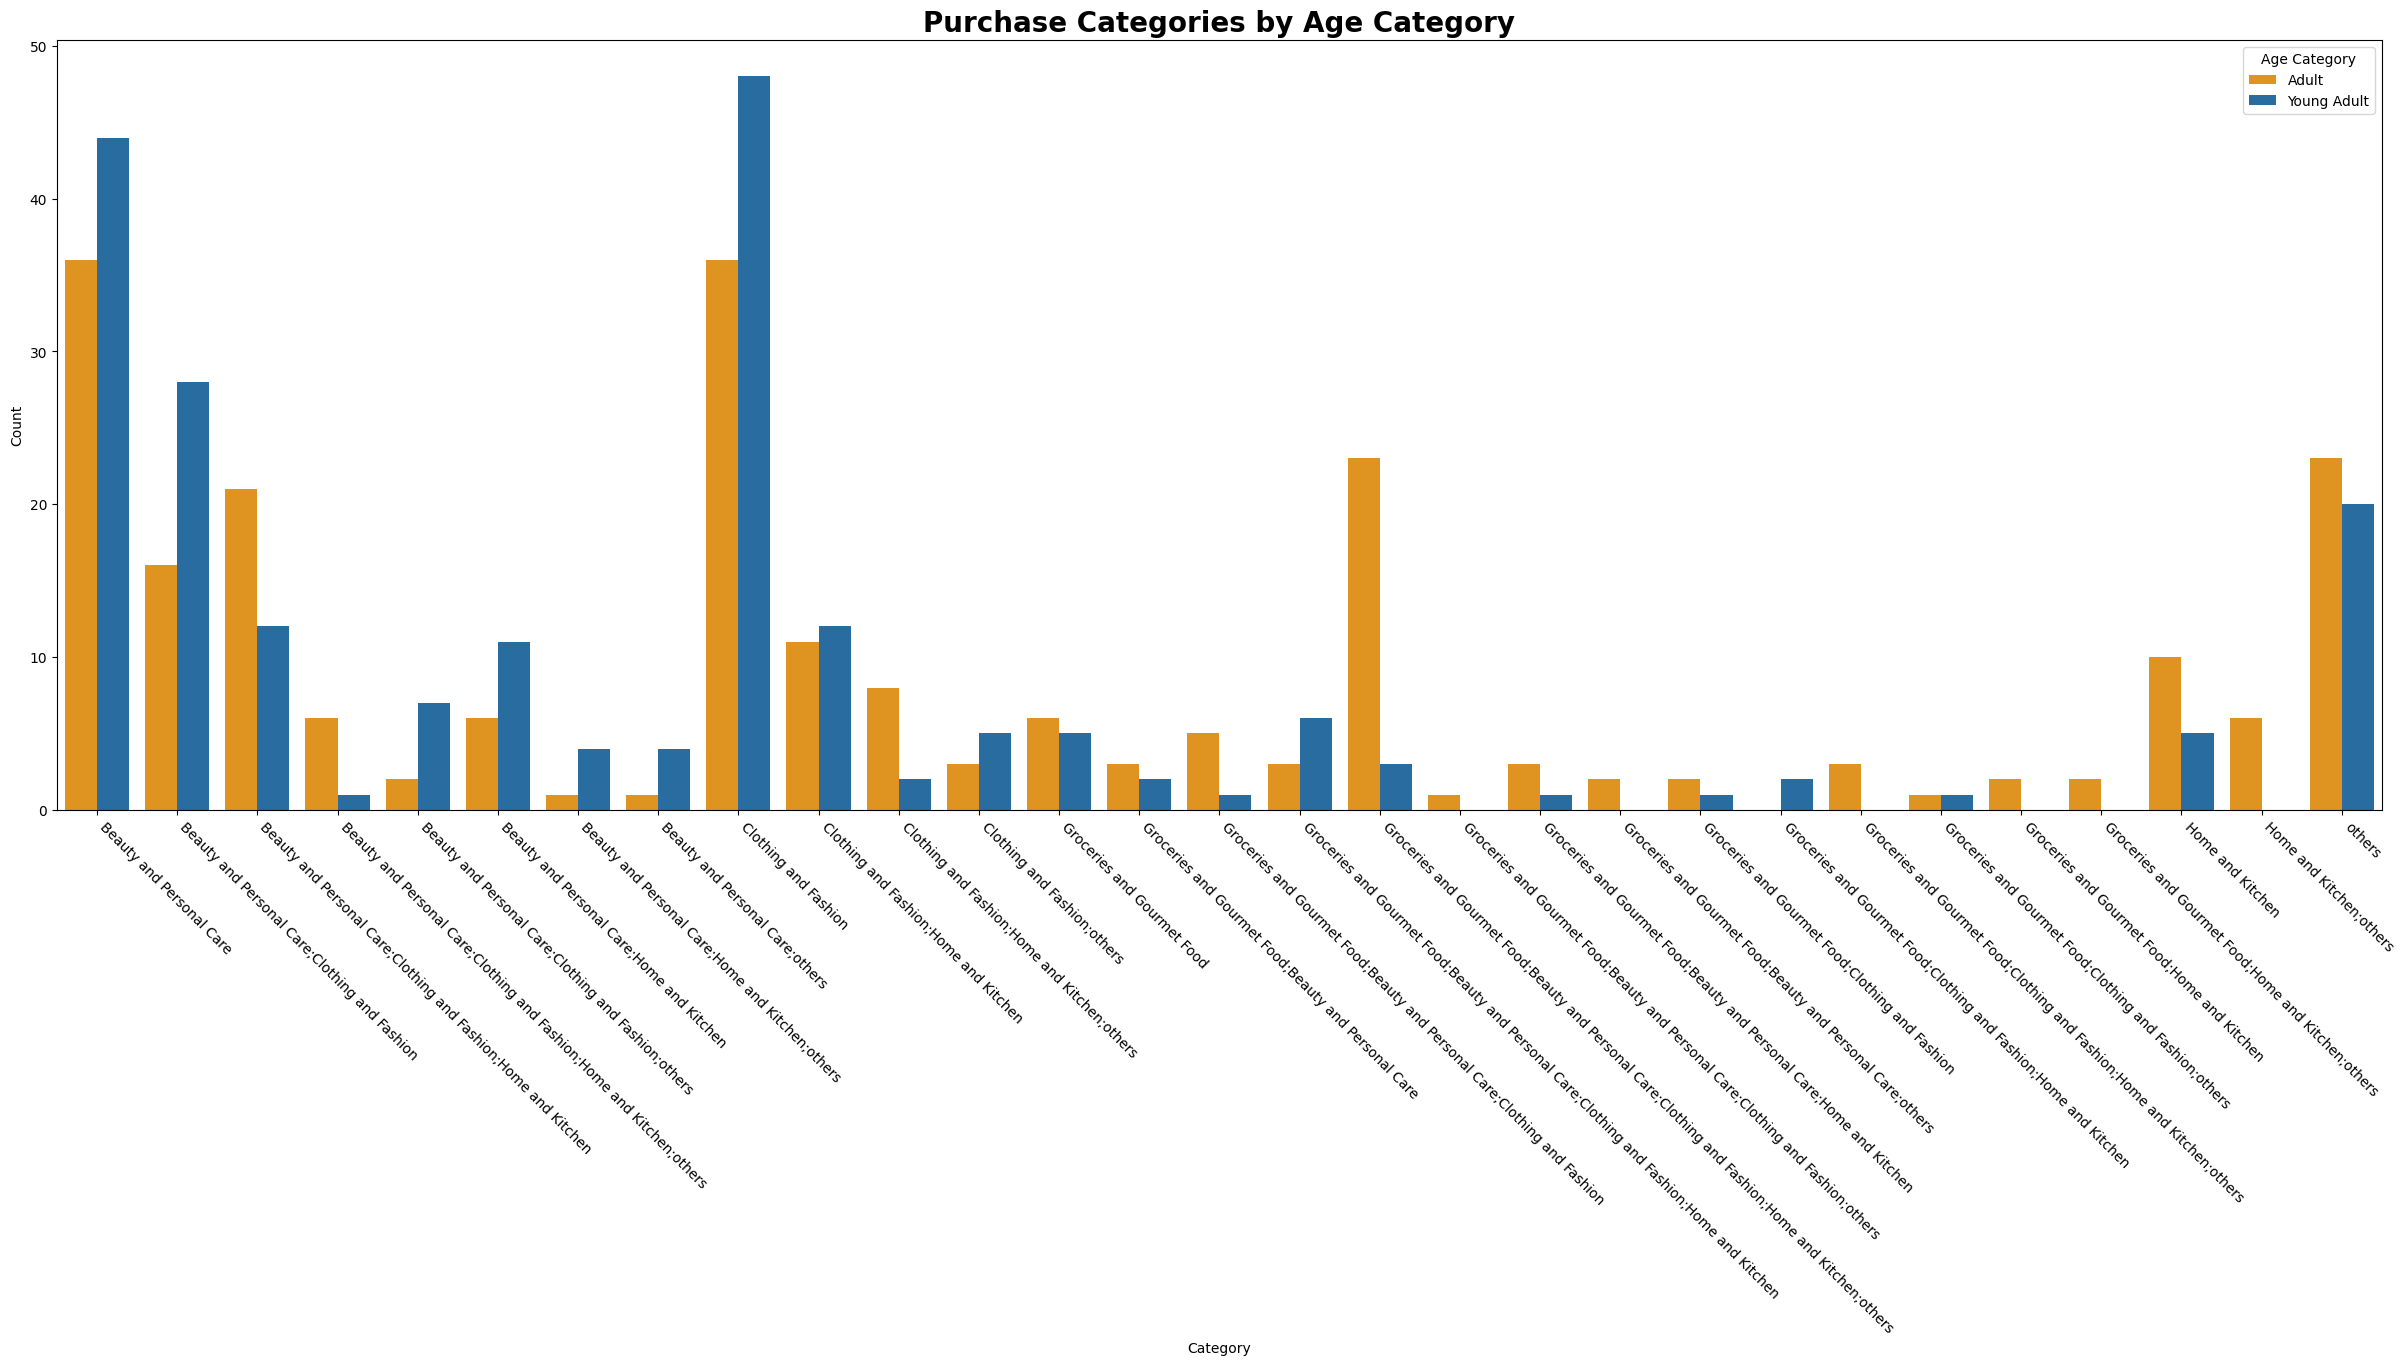

In [29]:
# Grouped bar: category × age category
df_cat_age = (
    df.groupby(["Purchase_Categories", "Age Category"])
      .agg(count=("Age Category", "count"))
      .reset_index()
)

#we're only keeping adults and young adults
df_cat_age = df_cat_age[
    df_cat_age["Age Category"].isin(["Adult", "Young Adult"])
]

plt.figure(figsize=(18, 8))
sns.barplot(data=df_cat_age, x="Purchase_Categories", y="count",
            hue="Age Category", palette=PALETTE[:2])
plt.title("Purchase Categories by Age Category", fontsize=20, fontweight='bold')
plt.xlabel("Category",fontsize=10)
plt.ylabel("Count",fontsize=10)
plt.xticks(rotation=-45, ha='left',fontsize=10)

plt.show()

**Interpretation:**
- Beauty & Personal Care and Clothing & Fashion together account for almost **50 %** of female purchases, confirming these are the platform's anchor categories for its primary demographic.
- Males shop more in Clothing & Fashion, though their overall volume is lower.
- Both Adults and Young Adults prioritize similar categories, but Young Adults show slightly higher engagement with Fashion & Clothing, consistent with trend-sensitivity in that age group.

## 6. Review Reliance & Customer Satisfaction

How much do customers trust and act on reviews and does that correlate with satisfaction?

> **Key finding:** Customers who rate reviews as highly important tend to report higher shopping satisfaction. Dissatisfied customers largely ignore reviews, suggesting either they make impulse purchases or distrust the review system.

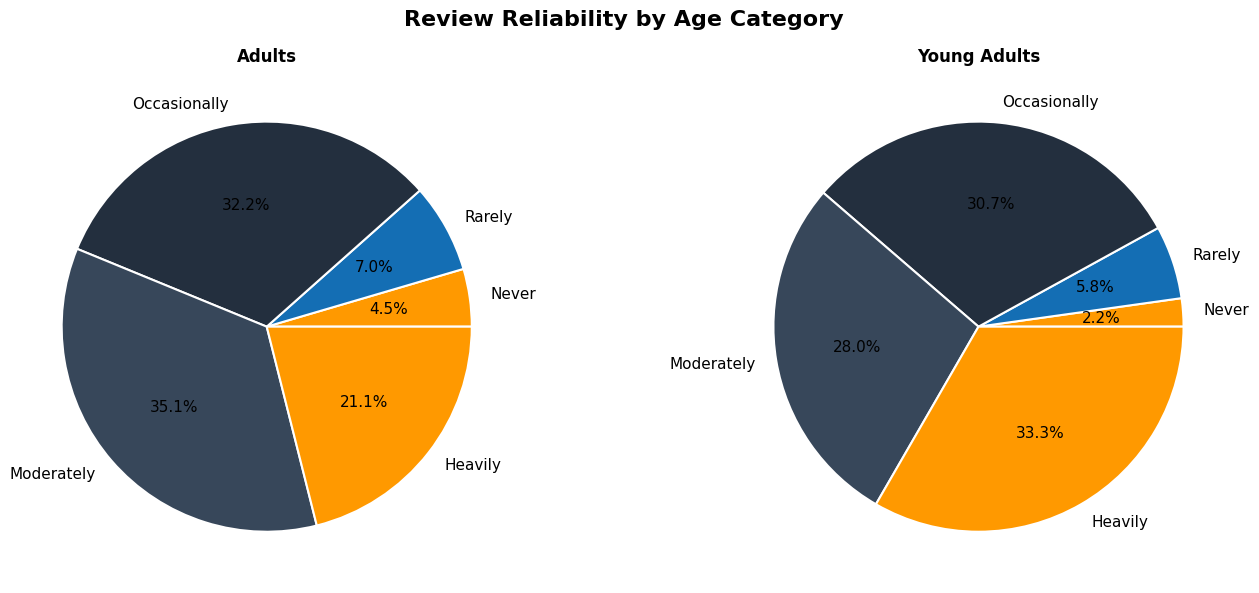

In [19]:
freq_order=["Never","Rarely","Occasionally","Moderately","Heavily"]

adult_counts = df[df["Age Category"] == "Adult"]["Review_Reliability"].value_counts().reindex(freq_order, fill_value=0)

young_counts = df[df["Age Category"] == "Young Adult"]["Review_Reliability"].value_counts().reindex(freq_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Review Reliability by Age Category",
             fontsize=16,
             fontweight='bold')


# Adults
axes[0].pie(
    adult_counts,
    labels=adult_counts.index,
    colors=PALETTE,
    **PIE_STYLE
)
axes[0].set_title("Adults", fontweight='bold')

# Young adults
axes[1].pie(
    young_counts,
    labels=young_counts.index,
    colors=PALETTE,
    **PIE_STYLE
)
axes[1].set_title("Young Adults", fontweight='bold')

plt.tight_layout()
plt.show()

Adults most commonly rely on reviews moderately (35.1%) and occasionally (32.2%). Young Adults, on the other hand, show a stronger tendency toward relying on reviews heavily (33.3%), **which is noticeably higher than Adults (21.1%)**.

This suggests that young Adults appear more influenced by customer reviews than Adults, as a larger proportion of Young Adults report relying on reviews heavily.

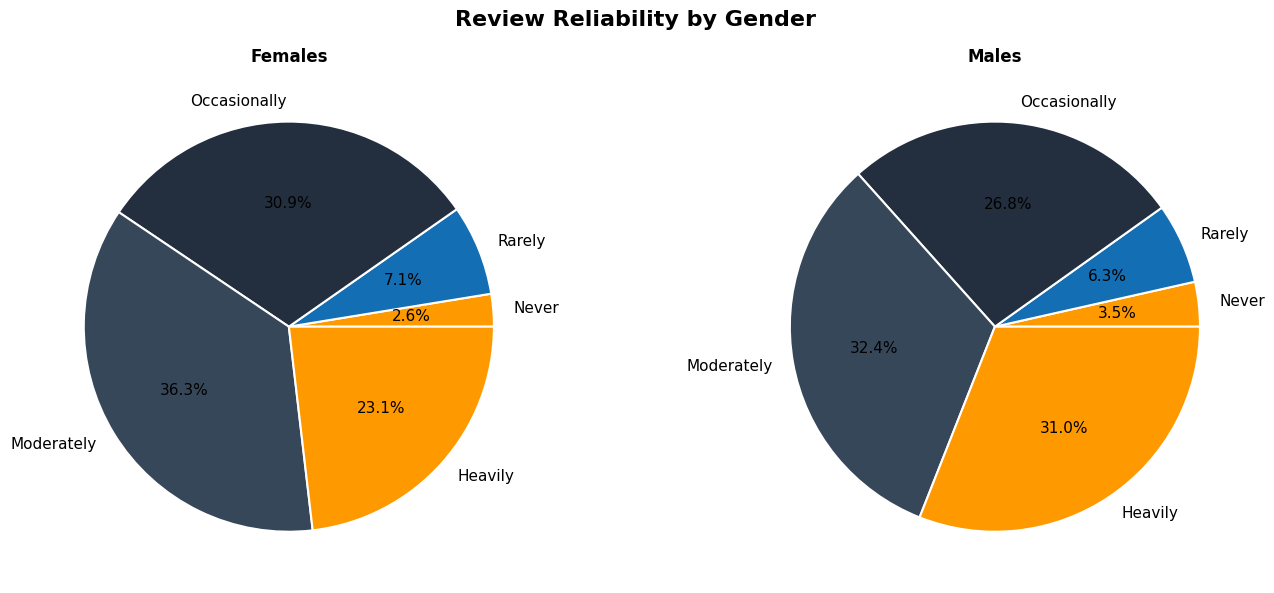

In [30]:
f_counts = df[df["Gender"] == "Female"]["Review_Reliability"].value_counts().reindex(freq_order, fill_value=0)

m_counts = df[df["Gender"] == "Male"]["Review_Reliability"].value_counts().reindex(freq_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Review Reliability by Gender",
             fontsize=16,
             fontweight='bold')

# Females
axes[0].pie(
    f_counts,
    labels=f_counts.index,
    colors=PALETTE,
    **PIE_STYLE
)
axes[0].set_title("Females", fontweight='bold')

# Males
axes[1].pie(
    m_counts,
    labels=m_counts.index,
    colors=PALETTE,
    **PIE_STYLE
)
axes[1].set_title("Males", fontweight='bold')

plt.tight_layout()
plt.show()

Females tend to rely on reviews moderately (36.3%) and occasionally (30.9%). Males, on the other hand, tend to rely on reviews heavily (31%) and moderately (36.3%), suggesting that men are more influenced by reviews than women.

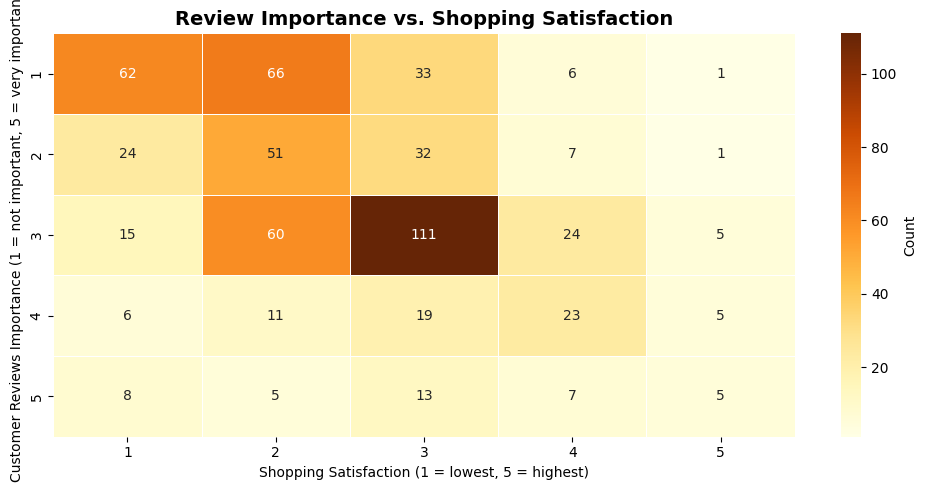

In [21]:
# Review importance vs shopping satisfaction (heatmap)
df_rev_sat = (
    df.groupby(["Customer_Reviews_Importance", "Shopping_Satisfaction"])
      .agg(count=("Shopping_Satisfaction", "count"))
      .reset_index()
)

pivot = df_rev_sat.pivot(index="Customer_Reviews_Importance",
                         columns="Shopping_Satisfaction", values="count").fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap="YlOrBr",
            linewidths=0.5, cbar_kws={"label": "Count"})
plt.title("Review Importance vs. Shopping Satisfaction", fontsize=14, fontweight='bold')
plt.xlabel("Shopping Satisfaction (1 = lowest, 5 = highest)")
plt.ylabel("Customer Reviews Importance (1 = not important, 5 = very important)")
plt.tight_layout()
plt.show()

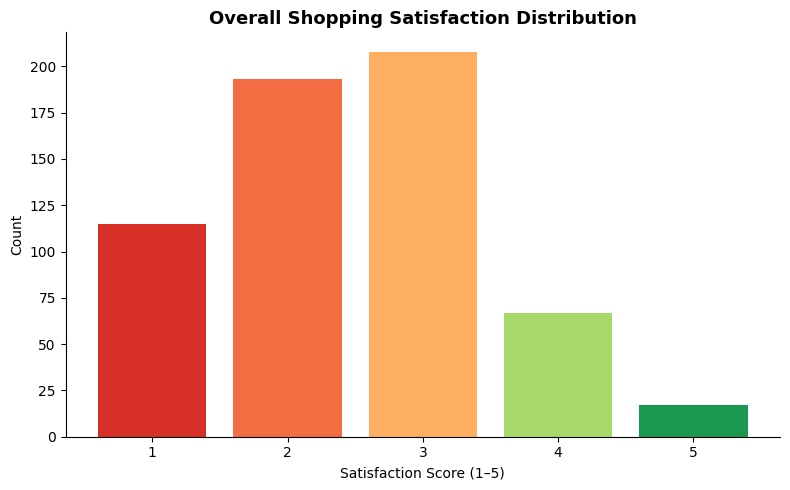

In [22]:
# Satisfaction distribution overall
plt.figure(figsize=(8, 5))
sat_counts = df["Shopping_Satisfaction"].value_counts().sort_index()
bars = plt.bar(sat_counts.index, sat_counts.values,
               color=["#d73027","#f46d43","#fdae61","#a6d96a","#1a9850"])
plt.title("Overall Shopping Satisfaction Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Satisfaction Score (1–5)")
plt.ylabel("Count")

sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:**
- Adults and Young Adults are the heaviest review-readers, they rely on them occasionally to heavily before purchasing.
- Men rely on reviews *moderately to heavily* more than women.
- The heatmap confirms a positive relationship: customers who score reviews as 4–5 in importance cluster at satisfaction scores of 3–5. This suggests that informed decision-making (via reviews) leads to better purchase outcomes.

## 7. Service Appreciation & Areas for Improvement

What do customers value most, and where do they want Amazon to do better?

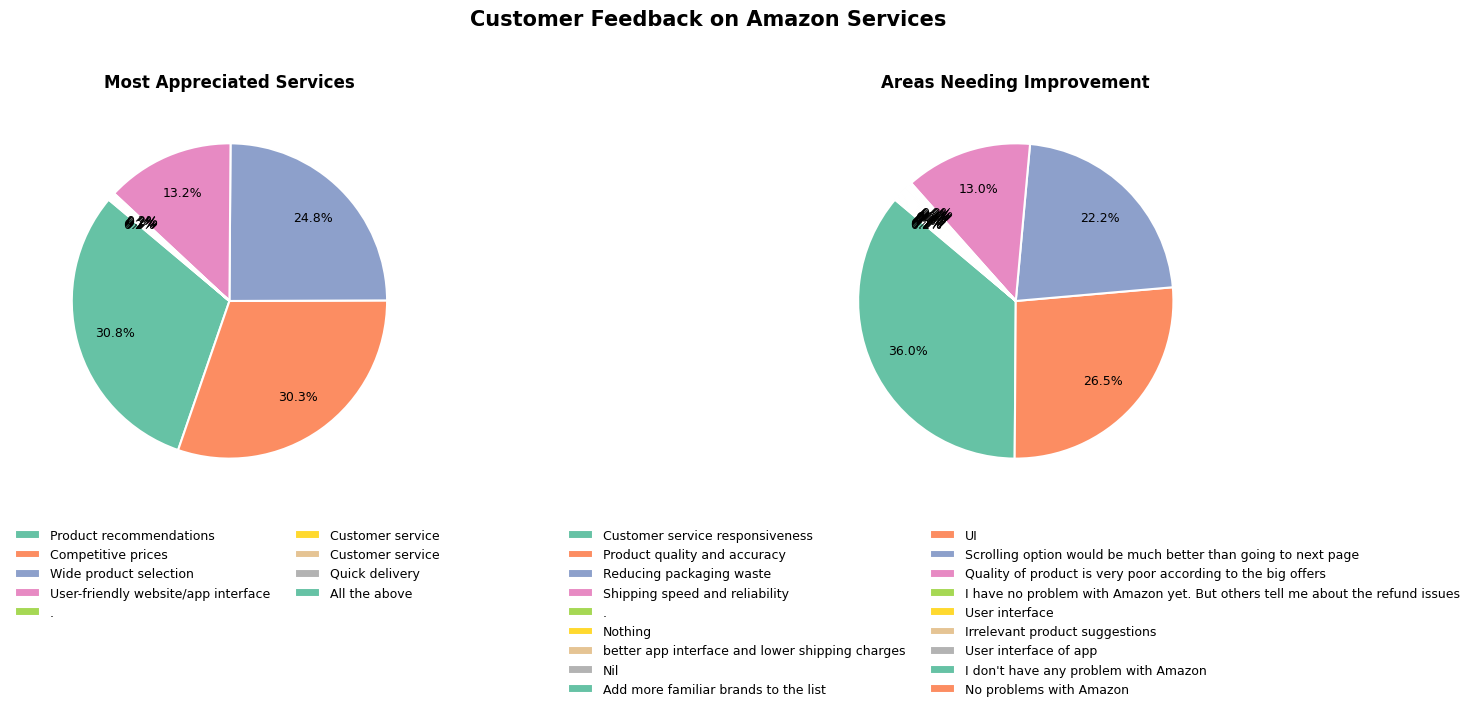

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Customer Feedback on Amazon Services", fontsize=15, fontweight='bold', y=1.02)

for ax, col, title in zip(axes,
    ["Service_Appreciation", "Improvement_Areas"],
    ["Most Appreciated Services", "Areas Needing Improvement"]
):
    counts = df[col].value_counts()
    wedges, _, autotexts = ax.pie(
        counts,
        labels=None,                    # ← no labels on the chart
        colors=sns.color_palette("Set2", len(counts)),
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=10)
    )
    for t in autotexts:
        t.set_fontsize(9)

    ax.legend(
        wedges,
        counts.index,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),    # ← below the pie
        ncol=2,                          # ← 2 columns so it stays compact
        fontsize=9,
        frameon=False
    )
    ax.set_title(title, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

**Interpretation:**
- **Product Recommendations** is the most appreciated feature, followed by **Competitive Prices** and **Wide Product Selection**.
- For improvements, customers most frequently cite **Customer service responsiveness** and **Better Product Quality**.

## 8. Additional Analysis: Search Behavior & Cart Abandonment

Going beyond demographics to understand *how* customers find products and what stops them from completing a purchase.

/tmp/ipykernel_13539/1913871712.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




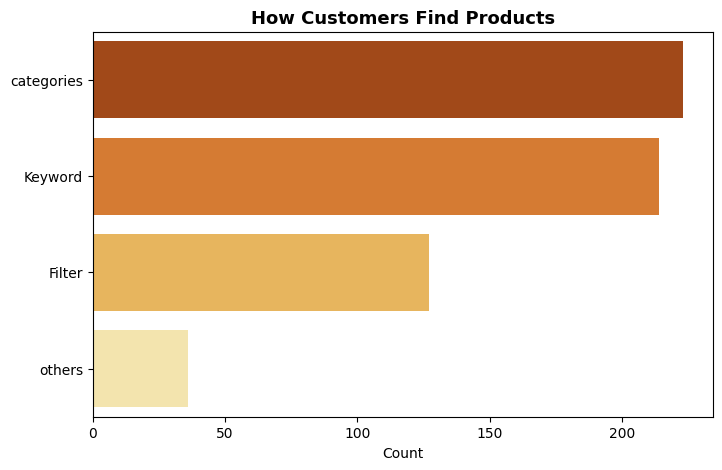

In [24]:
# Product search method distribution
plt.figure(figsize=(8, 5))
search_counts = df["Product_Search_Method"].value_counts()
sns.barplot(x=search_counts.values, y=search_counts.index, palette="YlOrBr_r")
plt.title("How Customers Find Products", fontsize=13, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")

plt.show()

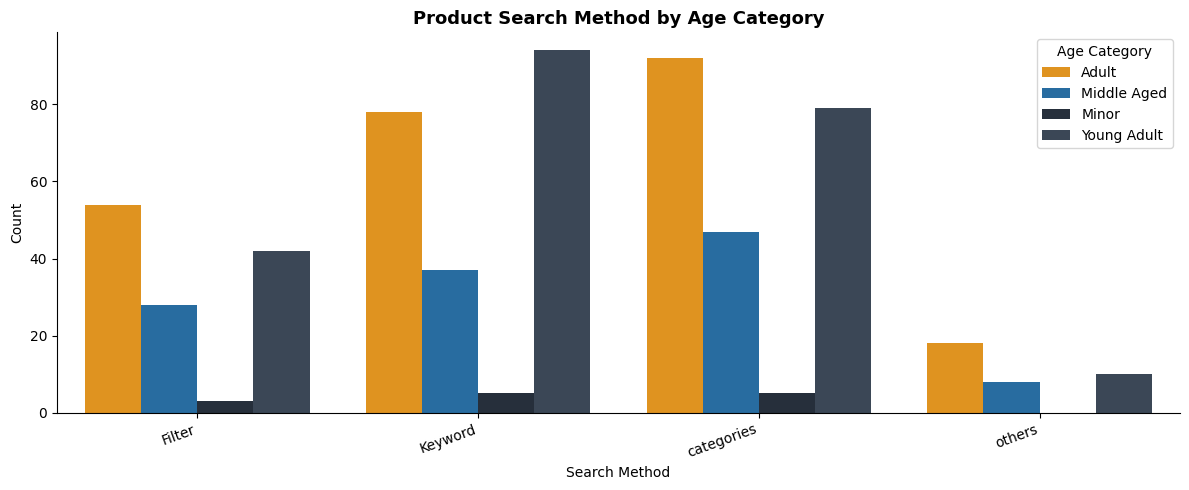

In [25]:
# Search method by age category
df_search_age = (
    df.groupby(["Product_Search_Method", "Age Category"])
      .agg(count=("Gender", "count"))
      .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=df_search_age, x="Product_Search_Method", y="count",
            hue="Age Category", palette=PALETTE)
plt.title("Product Search Method by Age Category", fontsize=13, fontweight='bold')
plt.xlabel("Search Method")
plt.ylabel("Count")
plt.xticks(rotation=20, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_13539/2020468172.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




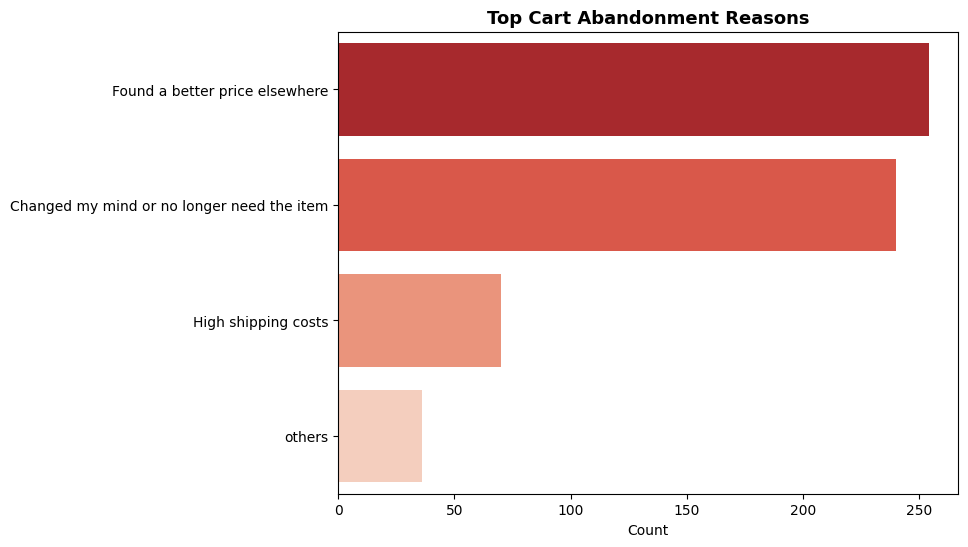

In [26]:
# Cart abandonment reasons (if column exists)
plt.figure(figsize=(8, 6))
ab_counts = df["Cart_Abandonment_Factors"].value_counts()
ax = sns.barplot(x=ab_counts.values, y=ab_counts.index, palette="Reds_r")
plt.title("Top Cart Abandonment Reasons", fontsize=13, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")

plt.show()


**Interpretation:**
- Most customers discover products by searching keywords and through category pages.
- Young Adults are more likely to use keywords, while older segments prefer using categories, indicating different UX engagement patterns by age.

## 9. Conclusions & Key Takeaways

| Theme | Finding |
|---|---|
| **Demographics** | Primary shopper: Adult or Young-Adult women; peak activity at night |
| **Categories** | Beauty & Fashion dominate for women; Fashion for men |
| **Reviews** | Review engagement correlates with satisfaction |
| **Services** | Personalized recommendations are the most valued feature |
| **Improvement** | Responsiveness is the main pain point |
| **Discovery** | Keywords and categories are the main product search method |
